# Sneha Singh
## DATA 266 — Homework 1
Autoregressive models + diabetes neural networks (PyTorch and TensorFlow)

In [1]:
# libraries for this homework
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# last 4 of my SJSU id
- 0670SID4 = 670
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# set seeds for python, numpy, torch, tensorflow
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

# HP_ID 4 = shorter training, same network
print("baseline [64, 32], lr 0.001, 30 epochs")
print("modified [64, 32], lr 0.001, 15 epochs")



SID4: 670
SEED: 670
SLICE: 670
HP_ID: 4
CLS_A: 0
CLS_B: 5
baseline [64, 32], lr 0.001, 30 epochs
modified [64, 32], lr 0.001, 15 epochs


## 1. What are autoregressive models? (5 points)

An autoregressive (AR) model is a time series model. It predicts the value at time t using previous values of the same series (lags). If I use 1 lag it is AR(1), if I use p lags it is AR(p). In lecture they also talked about ACF (autocorrelation), which is just how correlated the series is with a shifted copy of itself. High ACF at a lag means that lag is useful. For a stationary series the ACF usually gets smaller as the lag gets bigger.

This is a generative models class so they also showed the same idea as a probability chain. Instead of only learning a classifier, you model p(x) as:

p(x) = p(x1) p(x2|x1) p(x3|x1,x2) ...

so each step is predicted from what already came before. Linear AR is the stats version of that. A neural net can do the same thing for the conditionals (pNeural on the slide).

Real world examples: AR / ARIMA for stock prices or weather, VAR if there is more than one series, and GPT-style language models that generate the next token from the tokens so far.


## 2. Diabetes dataset: neural network implementation (10 points)

Preprocess → visualize → split 70/15/15 with `random_state=SEED` → baseline and HP_ID-modified models in PyTorch and TensorFlow.

In [2]:
# file has no column names
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "Pedigree", "Age", "Outcome"]
df = pd.read_csv("diabetes.csv", header=None, names=cols)

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df["Outcome"].value_counts())
print(df.describe())


(759, 9)
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.294118  0.487437       0.180328      -0.292929  0.000000  0.001490   
1    -0.882353 -0.145729       0.081967      -0.414141  0.000000 -0.207153   
2    -0.058824  0.839196       0.049180       0.000000  0.000000 -0.305514   
3    -0.882353 -0.105528       0.081967      -0.535354 -0.777778 -0.162444   
4     0.000000  0.376884      -0.344262      -0.292929 -0.602837  0.284650   

   Pedigree       Age  Outcome  
0 -0.531170 -0.033333        0  
1 -0.766866 -0.666667        1  
2 -0.492741 -0.633333        0  
3 -0.923997  0.000000        1  
4  0.887276 -0.600000        0  
Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64
Outcome
1    496
0    263
Name: count, dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   759.

### Visualize: correlation matrix, feature distributions

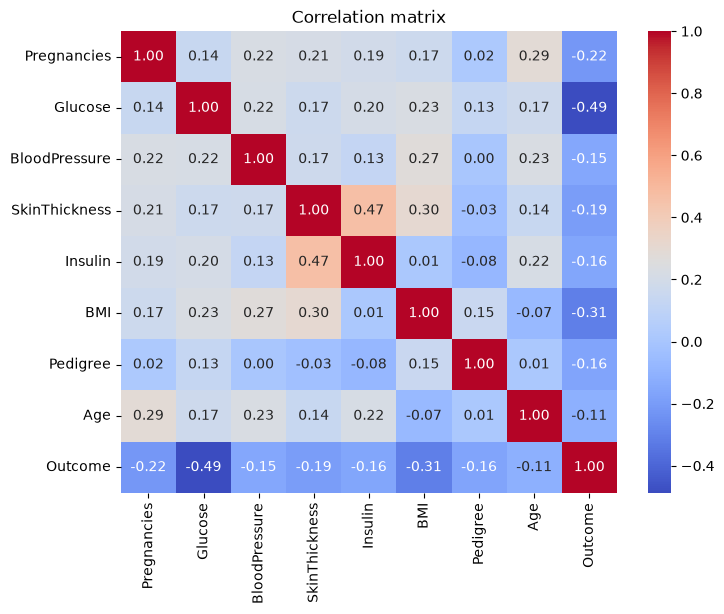

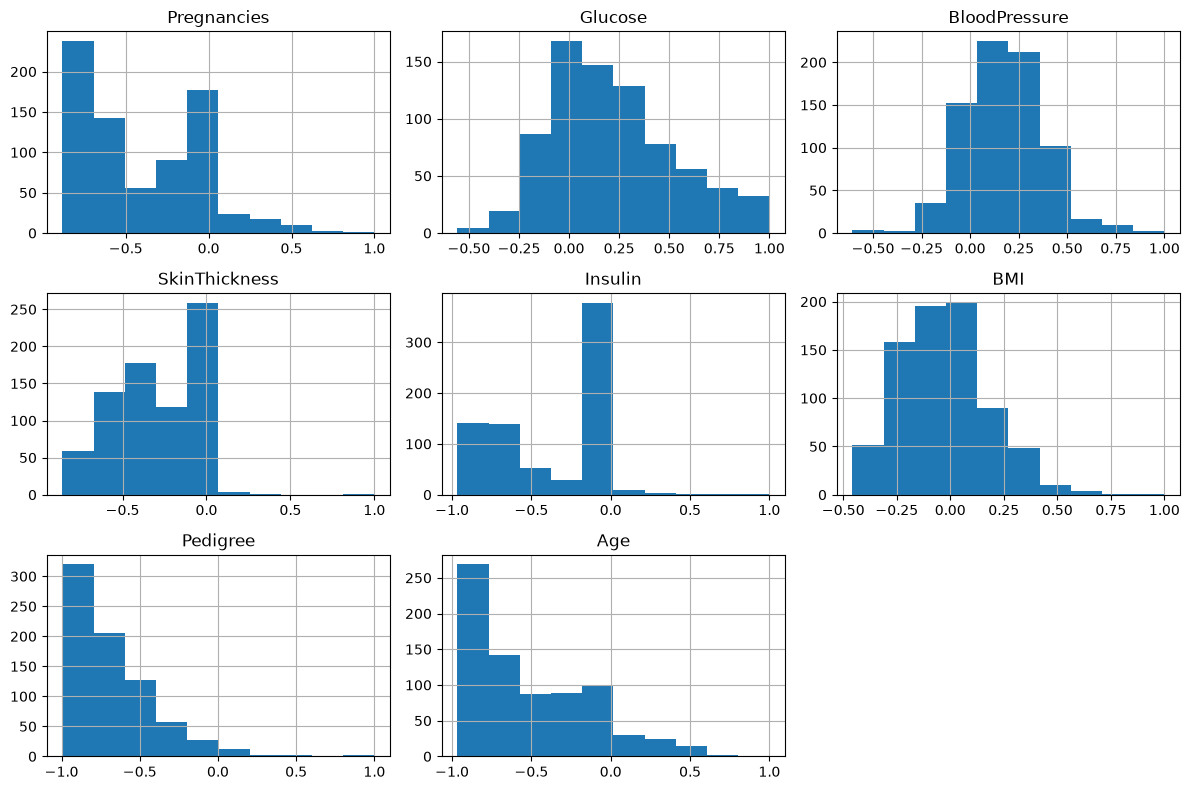

In [3]:
# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

# histograms of each feature
df.drop("Outcome", axis=1).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


### Train / validation / test split (70 / 15 / 15), `random_state=SEED`

In [4]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values.astype("float32")

# 15% test first, then 15% val from what is left (15/85) so it is 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=SEED)

print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

# fit scaler on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


train (531, 8) val (114, 8) test (114, 8)


### PyTorch: baseline `[64, 32]`, lr 0.001, 30 epochs  |  modified HP_ID 4: 15 epochs

baseline epoch 10 train 0.6488 val 0.6634
baseline epoch 20 train 0.6015 val 0.6293
baseline epoch 30 train 0.5522 val 0.5939
pytorch baseline test acc: 0.7017543859649122
modified epoch 5 train 0.6742 val 0.6809
modified epoch 10 train 0.6488 val 0.6634
modified epoch 15 train 0.6251 val 0.6466
pytorch modified test acc: 0.6228070175438597


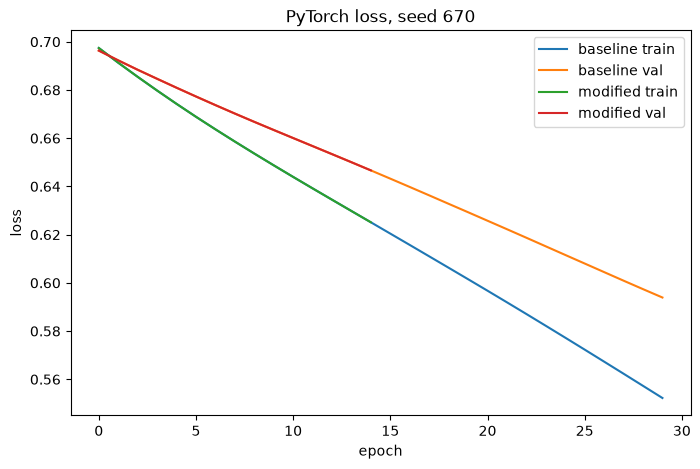

In [5]:
# turn the numpy split into tensors
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_v = torch.tensor(X_val, dtype=torch.float32)
y_v = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
X_ts = torch.tensor(X_test, dtype=torch.float32)

# ===== baseline: 30 epochs =====
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

base_train = []
base_val = []

for epoch in range(30):
    # train step
    model.train()
    optimizer.zero_grad()
    out = model(X_tr)
    loss = loss_fn(out, y_tr)
    loss.backward()
    optimizer.step()
    base_train.append(loss.item())

    # val loss (no backprop)
    model.eval()
    with torch.no_grad():
        v_loss = loss_fn(model(X_v), y_v)
        base_val.append(v_loss.item())

    if (epoch + 1) % 10 == 0:
        print("baseline epoch", epoch + 1, "train", round(loss.item(), 4), "val", round(v_loss.item(), 4))

# test acc
model.eval()
with torch.no_grad():
    y_hat = (torch.sigmoid(model(X_ts)) >= 0.5).reshape(-1).numpy()
base_acc = (y_hat == y_test).mean()
print("pytorch baseline test acc:", base_acc)

# ===== modified (HP_ID 4): same net, 15 epochs =====
torch.manual_seed(SEED)

model2 = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn2 = nn.BCEWithLogitsLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

mod_train = []
mod_val = []

for epoch in range(15):
    model2.train()
    optimizer2.zero_grad()
    out = model2(X_tr)
    loss = loss_fn2(out, y_tr)
    loss.backward()
    optimizer2.step()
    mod_train.append(loss.item())

    model2.eval()
    with torch.no_grad():
        v_loss = loss_fn2(model2(X_v), y_v)
        mod_val.append(v_loss.item())

    if (epoch + 1) % 5 == 0:
        print("modified epoch", epoch + 1, "train", round(loss.item(), 4), "val", round(v_loss.item(), 4))

model2.eval()
with torch.no_grad():
    y_hat = (torch.sigmoid(model2(X_ts)) >= 0.5).reshape(-1).numpy()
mod_acc = (y_hat == y_test).mean()
print("pytorch modified test acc:", mod_acc)

# plot both on one figure
plt.figure(figsize=(8, 5))
plt.plot(base_train, label="baseline train")
plt.plot(base_val, label="baseline val")
plt.plot(mod_train, label="modified train")
plt.plot(mod_val, label="modified val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("PyTorch loss, seed 670")
plt.legend()
plt.show()


### TensorFlow: same baseline and HP_ID 4 modified model

tensorflow baseline test acc: 0.719298243522644
tensorflow modified test acc: 0.6491228342056274


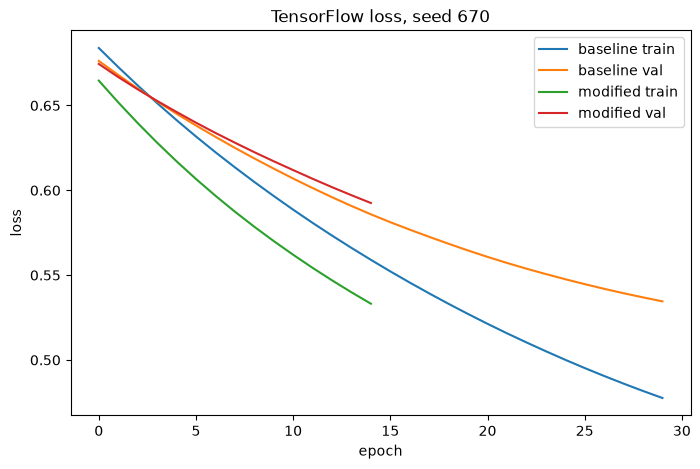

In [6]:
# same split as pytorch, full batch so it matches
bs = len(X_train)

# --- baseline: 30 epochs 
tf.random.set_seed(SEED)

model_tf = Sequential()
model_tf.add(Input(shape=(8,)))
model_tf.add(Dense(64, activation="relu"))
model_tf.add(Dense(32, activation="relu"))
model_tf.add(Dense(1, activation="sigmoid"))

model_tf.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])

# verbose=0 so it doesnt spam 30 lines
hist = model_tf.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=30, batch_size=bs, verbose=0)

tf_base_loss, tf_base_acc = model_tf.evaluate(X_test, y_test, verbose=0)
print("tensorflow baseline test acc:", tf_base_acc)

# ===== modified (HP_ID 4): same net, 15 epochs =====
tf.random.set_seed(SEED)

model_tf2 = Sequential()
model_tf2.add(Input(shape=(8,)))
model_tf2.add(Dense(64, activation="relu"))
model_tf2.add(Dense(32, activation="relu"))
model_tf2.add(Dense(1, activation="sigmoid"))

model_tf2.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])

hist2 = model_tf2.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=15, batch_size=bs, verbose=0)

tf_mod_loss, tf_mod_acc = model_tf2.evaluate(X_test, y_test, verbose=0)
print("tensorflow modified test acc:", tf_mod_acc)

# one figure, same as pytorch
plt.figure(figsize=(8, 5))
plt.plot(hist.history["loss"], label="baseline train")
plt.plot(hist.history["val_loss"], label="baseline val")
plt.plot(hist2.history["loss"], label="modified train")
plt.plot(hist2.history["val_loss"], label="modified val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("TensorFlow loss, seed 670")
plt.legend()
plt.show()


### Three training seeds (SEED, SEED+1, SEED+2) and SEED-run loss curves

In [7]:
# same split as before, only the training seed changes
# I already plotted seed 670, this cell is just mean/std over 3 seeds
seeds = [SEED, SEED + 1, SEED + 2]
print("seeds:", seeds)

pt_base_accs = []
pt_mod_accs = []
tf_base_accs = []
tf_mod_accs = []
bs = len(X_train)

for s in seeds:
    print("\n--- seed", s, "---")

    # pytorch baseline, 30 epochs
    torch.manual_seed(s)
    model = nn.Sequential(
        nn.Linear(8, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(30):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_hat = (torch.sigmoid(model(X_ts)) >= 0.5).reshape(-1).numpy()
    acc = (y_hat == y_test).mean()
    pt_base_accs.append(acc)
    print("pytorch baseline", acc)

    # pytorch modified, 15 epochs
    torch.manual_seed(s)
    model2 = nn.Sequential(
        nn.Linear(8, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )
    loss_fn2 = nn.BCEWithLogitsLoss()
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
    for epoch in range(15):
        model2.train()
        optimizer2.zero_grad()
        loss = loss_fn2(model2(X_tr), y_tr)
        loss.backward()
        optimizer2.step()
    model2.eval()
    with torch.no_grad():
        y_hat = (torch.sigmoid(model2(X_ts)) >= 0.5).reshape(-1).numpy()
    acc = (y_hat == y_test).mean()
    pt_mod_accs.append(acc)
    print("pytorch modified", acc)

    # tensorflow baseline, 30 epochs
    tf.random.set_seed(s)
    model_tf = Sequential()
    model_tf.add(Input(shape=(8,)))
    model_tf.add(Dense(64, activation="relu"))
    model_tf.add(Dense(32, activation="relu"))
    model_tf.add(Dense(1, activation="sigmoid"))
    model_tf.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])
    model_tf.fit(X_train, y_train, epochs=30, batch_size=bs, verbose=0)
    acc = model_tf.evaluate(X_test, y_test, verbose=0)[1]
    tf_base_accs.append(acc)
    print("tensorflow baseline", acc)

    # tensorflow modified, 15 epochs
    tf.random.set_seed(s)
    model_tf2 = Sequential()
    model_tf2.add(Input(shape=(8,)))
    model_tf2.add(Dense(64, activation="relu"))
    model_tf2.add(Dense(32, activation="relu"))
    model_tf2.add(Dense(1, activation="sigmoid"))
    model_tf2.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])
    model_tf2.fit(X_train, y_train, epochs=15, batch_size=bs, verbose=0)
    acc = model_tf2.evaluate(X_test, y_test, verbose=0)[1]
    tf_mod_accs.append(acc)
    print("tensorflow modified", acc)

print("\n==== mean and std ====")
print("pytorch baseline   ", pt_base_accs, "mean", round(np.mean(pt_base_accs), 4), "std", round(np.std(pt_base_accs), 4))
print("pytorch modified   ", pt_mod_accs, "mean", round(np.mean(pt_mod_accs), 4), "std", round(np.std(pt_mod_accs), 4))
print("tensorflow baseline", tf_base_accs, "mean", round(np.mean(tf_base_accs), 4), "std", round(np.std(tf_base_accs), 4))
print("tensorflow modified", tf_mod_accs, "mean", round(np.mean(tf_mod_accs), 4), "std", round(np.std(tf_mod_accs), 4))


seeds: [670, 671, 672]

--- seed 670 ---
pytorch baseline 0.7017543859649122
pytorch modified 0.6228070175438597
tensorflow baseline 0.6578947305679321
tensorflow modified 0.6315789222717285

--- seed 671 ---
pytorch baseline 0.6403508771929824
pytorch modified 0.5964912280701754
tensorflow baseline 0.6929824352264404
tensorflow modified 0.6491228342056274

--- seed 672 ---
pytorch baseline 0.6666666666666666
pytorch modified 0.5789473684210527
tensorflow baseline 0.6842105388641357
tensorflow modified 0.6315789222717285

==== mean and std ====
pytorch baseline    [np.float64(0.7017543859649122), np.float64(0.6403508771929824), np.float64(0.6666666666666666)] mean 0.6696 std 0.0252
pytorch modified    [np.float64(0.6228070175438597), np.float64(0.5964912280701754), np.float64(0.5789473684210527)] mean 0.5994 std 0.018
tensorflow baseline [0.6578947305679321, 0.6929824352264404, 0.6842105388641357] mean 0.6784 std 0.0149
tensorflow modified [0.6315789222717285, 0.6491228342056274, 0.631

### Conclusion

HP_ID 4 only changed the schedule: 15 epochs instead of 30. Same layers `[64, 32]` and same lr `0.001`.

On the seed 670 test set the shorter run is worse in both frameworks (PyTorch 0.70 → 0.62, TensorFlow 0.72 → 0.65). The loss plots for seed 670 show train and val loss still going down at epoch 15, and the 30-epoch baseline keeps going lower. Val loss is not turning up, so this is not overfitting. The modified model is underfitting / stopped too early.

So the assigned change did not help. Extra epochs helped more than stopping at 15.
